 #### Práctica 2: Procesamiento de datatasets
 # Diabetes en México

### Introducción
La diabetes mellitus comprende un grupo de enfermedades metabólicas cuyo principal rasgo en común es la hiperglucemia, es decir, una concentración de glucosa en sangre superior a los valores normales. Esta alteración puede deberse a una deficiencia en la secreción de insulina, a una disminución en la eficacia de su acción metabólica o a una combinación de ambos factores. Cuando la hiperglucemia se mantiene de forma prolongada, puede provocar diversas complicaciones crónicas y ocasionar daños progresivos en distintos órganos y tejidos, particularmente en los vasos sanguíneos, los nervios y el sistema cardiovascular. (De Santiago Nocito, 2010)

En 2021, se estimó que aproximadamente 529 millones de personas vivían con diabetes tipo 2 en el mundo, lo que representaba alrededor del 6.1 % de la población mundial. Asimismo, se proyecta que para 2050 esta cifra podría alcanzar aproximadamente 1,300 millones de personas, equivalente al 9.8 % de la población. En América Latina, y particularmente en México, la elevada prevalencia de la DT2 representa un desafío relevante, no solo por las complicaciones asociadas y su impacto en la calidad de vida de la población, sino también por la carga económica que genera para los sistemas de salud y la sociedad. (Hernández-Ávila, M, 2013)

Bajo este contexto, el dataset utilizado para el desarrollo de esta práctica fue elaborado a partir de información pública proveniente de la Encuesta Nacional de Salud y Nutrición (ENSANUT) 2024, realizada en México y publicada por el Instituto Nacional de Salud Pública (INSP). La ENSANUT recopila información sobre las condiciones de salud y nutrición de la población mexicana mediante cuestionarios, mediciones antropométricas y, para determinados participantes, la obtención y análisis de muestras biológicas. (Reyes-García, A, et al., 2025) (Encuesta Nacional de Salud y Nutrición, 2024)

### Dataset
El dataset utilizado integra información demográfica, antropométrica y bioquímica de 2,549 participantes, con el propósito de analizar distintos factores asociados con la diabetes y clasificar el nivel de riesgo que presenta cada individuo de desarrollar esta enfermedad. El conjunto de datos está compuesto por 24 atributos, los cuales incluyen variables de identificación, variables categóricas y numéricas.(Jiménez & Lee, 2026)

| Atributo | Descripción |
|---|---|
| folio_i | Identificador único del hogar |
| folio_int | Identificador único del individuo | 
| sexo | Sexo del individuo (1 = masculino, 2 = femenino) | 
| edad | Edad del individuo en años |
| Ciudad | Ciudad de residencia | 
| Peso | Peso corporal en kilogramos | 
| Estatura | Estatura del individuo en centímetros | 
| imc | Índice de masa corporal (IMC) | Numérica continua |
| muestra_suero | Indica si se obtuvo una muestra de suero (0 = no, 1 = sí) |
| ac_urico | Concentración de ácido úrico en sangre | 
| albu | Concentración de albúmina en sangre | 
| col_hdl | Nivel de colesterol HDL | 
| col_ldl | Nivel de colesterol LDL | 
| colest | Nivel de colesterol total | 
| creat | Nivel de creatinina | 
| glu_suero | Concentración de glucosa sérica | 
| insulina | Concentración de insulina en sangre | 
| trig | Nivel de triglicéridos | 
| hb1ac | Hemoglobina glucosilada (HbA1c) | 
| ponde_venosa | Ponderador correspondiente a la muestra venosa | 
| estrato | Estrato utilizado en el diseño muestral | 
| est_sel | Unidad primaria de muestreo |
| ponde_hemo | Ponderador correspondiente a la muestra de hemoglobina 
| riesgo_diabetes_cat | Categoría de riesgo de diabetes (0 = bajo, 1 = moderado, 2 = alto) |


#### Librerias

In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTENC

### Análisis exploratorio

La variable objetivo del dataset corresponde al riesgo de diabetes. Esta variable permite clasificar a los participantes de acuerdo con su nivel de riesgo que se divide en tres categorías (0, 1 y 2) y permite analizar cómo distintas características demográficas, antropométricas y bioquímicas se relacionan con los diferentes niveles de riesgo.

Cantidad de participantes por categoría de riesgo:
Riesgo 0    1697
Riesgo 1      12
Riesgo 2     840
Name: count, dtype: int64


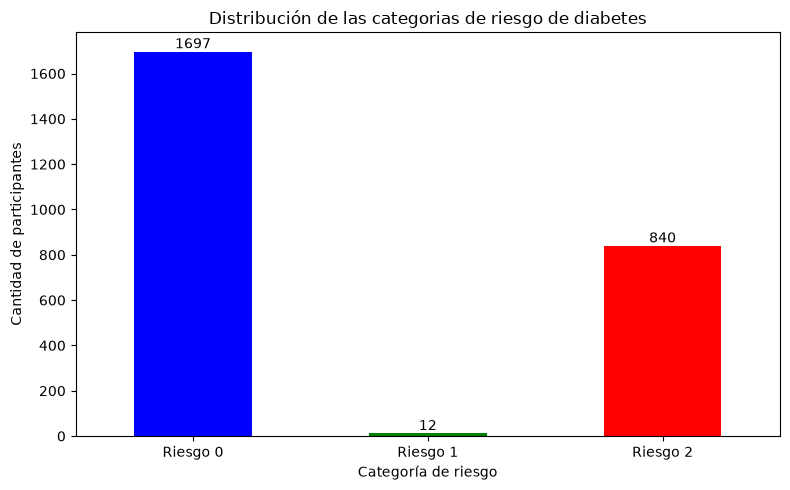

In [77]:
df= pd.read_csv('Diabetes_Mexico.csv')
# Conteo de participantes por categoría de riesgo de diabetes
riesgo_diabetes = pd.to_numeric(df['riesgo_diabetes_cat'], errors='coerce')
conteo_riesgo = riesgo_diabetes.value_counts().reindex([0, 1, 2], fill_value=0).sort_index()
conteo_riesgo.index = ['Riesgo 0', 'Riesgo 1', 'Riesgo 2']

print('Cantidad de participantes por categoría de riesgo:')
print(conteo_riesgo)

# Gráfica de barras de las categorías de riesgo
plt.figure(figsize=(8, 5))
ax = conteo_riesgo.plot(kind='bar', color=['blue', 'green', 'red'])
plt.title('Distribución de las categorias de riesgo de diabetes')
plt.xlabel('Categoría de riesgo')
plt.ylabel('Cantidad de participantes')
plt.xticks(rotation=0)

for barra in ax.patches:
    ax.annotate(
        f'{int(barra.get_height())}',
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

Se puede observar con la gráfica un desbalance considerable entre las categorías. La categoría 0 concentra la mayor cantidad de participantes, con 1,697 registros, seguida de la categoría 2 con 840, mientras que la categoría 1 cuenta únicamente con 12 observaciones. Este aspecto deberá considerarse al interpretar las comparaciones entre grupos, especialmente en el caso de la categoría 1, ya que su reducido número de observaciones puede limitar la representatividad. Ahora bien, vamos a anlaizar las variable númericas. 

In [78]:
describe = df.describe()
describe
df_antes_limpieza = df.copy() #se usara para comparar los datos antes y despues de la limpieza

Como se puede observar, algunas de las variables presentan ciertas irregularidades. La tabla muestra únicamente los atributos numéricos y permite identificar, en primer lugar, la presencia de valores faltantes. Un ejemplo de ello es la variable edad, cuyo count indica que se dispone de información para 2,524 de los 2,549 participantes del dataset. Esto significa que 25 registros no cuentan con información para esta variable, lo que representa aproximadamente el 0.98 % del total.

Además, en esta misma variable se identificó una irregularidad relacionada con la presencia de valores fuera del rango esperado. En particular, se encontraron cuatro participantes registrados con una edad de −7,975, un valor no válido considerando la natruraleza de la variable. Estos registros sugieren la presencia de posibles errores de captura y por lo tanto, deberán ser examinados y tratados durante la etapa de limpieza y preparación de los datos



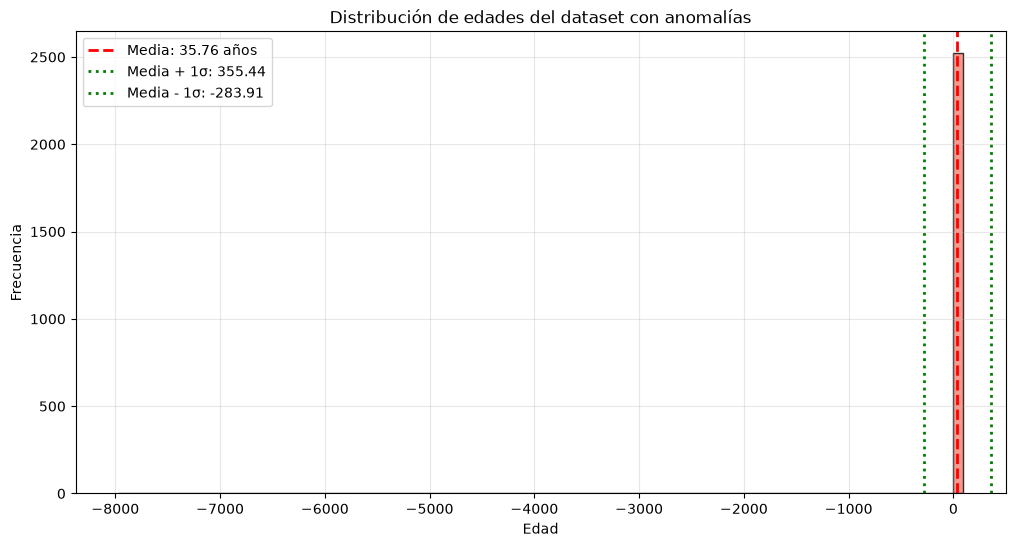

Media de edades con anomalías: 35.76 años
Desviación estándar con anomalías: 319.67 años
Número de valores negativos anómalos: 4
Valores negativos anómalos: [-7975.]


In [79]:
edades_con_anomalias = pd.to_numeric(df['edad'],errors='coerce').dropna()
media = np.mean(edades_con_anomalias)
desviacion = np.std(edades_con_anomalias, ddof=1)

plt.figure(figsize=(12, 6))
plt.hist(edades_con_anomalias, bins=80, color='salmon', edgecolor='black', alpha=0.8)
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f} años')
plt.axvline(media + desviacion, color='green', linestyle=':', linewidth=2, label=f'Media + 1σ: {media + desviacion:.2f}')
plt.axvline(media - desviacion, color='green', linestyle=':', linewidth=2, label=f'Media - 1σ: {media - desviacion:.2f}')
plt.title('Distribución de edades del dataset con anomalías')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f'Media de edades con anomalías: {media:.2f} años')
print(f'Desviación estándar con anomalías: {desviacion:.2f} años')
print(f'Número de valores negativos anómalos: {(edades_con_anomalias < 0).sum()}')
print(f'Valores negativos anómalos: {edades_con_anomalias[edades_con_anomalias < 0].unique()}')

Con esta figura se puede observar que aunque estos casos representan una proporción muy pequeña del dataset, tuvieron un efecto considerable sobre la desviación estándar, aumentando artificialmente la dispersión de la variable. Esto demuestra cómo incluso una cantidad reducida de valores extremos puede alterar las medidas estadísticas y generar una representación poco precisa de la distribución real de los datos. Por esta razón, fue es muy importante identificarlos y tratarlos adecuadamente en el apartado de limpieza.

Durante la exploración del dataset también se identificó un problema recurrente relacionado con los tipos de datos. Varias variables que, por su naturaleza, deberían ser numéricas fueron interpretadas como objetos (object), variables como:  Peso, Estatura, ac_urico, albu, col_hdl, creat, insulina. Esta inconsistencia puede estar relacionada con el formato utilizado durante la captura de los datos, particularmente con el uso de comas como separador decimal en lugar de puntos, lo que impide que estas variables sean reconocidas automáticamente como valores numéricos.

Esta situación representa un problema para el análisis, ya que mientras las variables permanezcan como objetos no es posible aplicar correctamente diferentes operaciones estadísticas y métodos de visualización propios de datos numéricos. Por esta razón, es necesario realizar una transformación previa, reemplazando el separador decimal y convirtiendo cada atributo al tipo de dato correspondiente.

In [80]:
# Identificar las variables almacenadas como tipo object
columnas_object = df.select_dtypes(include=['str']).columns

print("Variables almacenadas como tipo object:")
for columna in columnas_object:
    print(f"- {columna}")

Variables almacenadas como tipo object:
- folio_i
- folio_int
- sexo
- Ciudad
- Peso
- Estatura
- ac_urico
- albu
- col_hdl
- creat
- insulina
- ponde_venosa
- ponde_hemo


A demás, las variabls Peso, Estatura e IMC presentan un alto pocentaje de varoles faltantes. 

In [81]:
variables_faltantes = ['Estatura', 'Peso', 'imc']
conteo_faltantes = df[variables_faltantes].isna().sum()

print('Conteo de datos faltantes por variable:')
print(conteo_faltantes)

Conteo de datos faltantes por variable:
Estatura     720
Peso         720
imc         2514
dtype: int64


A partir del análisis exploratorio fue posible identificar los principales problemas presentes en el dataset, entre ellos valores faltantes, valores anómalos y variables almacenadas con tipos de datos incorrectos. Además, se identificó un desbalance considerable en la variable objetivo, ya que algunas categorías cuentan con un número de registros mucho mayor que otras. Una vez identificadas estas características y problemas del conjunto de datos, se procede al apartado de preprocesamiento, donde se aplicarán diferentes técnicas con el objetivo de mejorar la calidad y estructura de los datos antes de realizar análisis posteriores.

### Limpieza de datos
Como primera etapa de la limpieza se va realizar la corrección de los tipos de datos. Durante el análisis exploratorio se identificaron diferentes atributos almacenados como object que, por la naturaleza de la información que representan, deberían ser variables numéricas. Al revisar sus valores se observó que esto se debía principalmente al uso de la coma como separador decimal.

In [82]:
# Convertir variables de texto a valores numéricos
variables_numericas = ['Peso', 'Estatura', 'ac_urico', 'albu', 'col_hdl', 'creat', 'insulina','ponde_venosa', 'ponde_hemo']
for variable in variables_numericas:
    df[variable] = pd.to_numeric(
        df[variable].astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    )

print('Tipos de datos después de la conversión:')
print(df[variables_numericas].dtypes)

# Descripción estadística de las variables ya convertidas
print('\nDescripción estadística de las variables numéricas tratadas:')
descripcion_estadistica = df[variables_numericas].describe()
descripcion_estadistica

Tipos de datos después de la conversión:
Peso            float64
Estatura        float64
ac_urico        float64
albu            float64
col_hdl         float64
creat           float64
insulina        float64
ponde_venosa    float64
ponde_hemo      float64
dtype: object

Descripción estadística de las variables numéricas tratadas:


,Peso,Estatura,ac_urico,albu,col_hdl,creat,insulina,ponde_venosa,ponde_hemo
count,1829.000000,1829.000000,2549.000000,2549.000000,2549.000000,2549.000000,2549.000000,2450.000000,1569.000000
mean,76.646528,159.751011,4.920282,3.425657,38.418674,0.733076,12.272734,34049.741688,24957.387367
std,21.037884,11.088696,1.441246,0.600118,10.691394,0.499284,15.375089,58133.799615,39948.298340
min,31.700000,126.500000,0.800000,1.100000,6.200000,0.200000,0.200000,533.153656,870.042562
25%,63.650000,152.500000,3.900000,3.000000,31.000000,0.560000,5.300000,8690.937493,6652.767680
50%,73.750000,158.800000,4.800000,3.500000,37.000000,0.670000,8.400000,17225.159260,12302.591610
75%,86.100000,165.600000,5.800000,3.800000,44.000000,0.810000,14.100000,35292.298525,25069.127340
max,222.220000,222.200000,16.400000,6.000000,98.000000,12.900000,395.000000,876795.218900,484204.868800


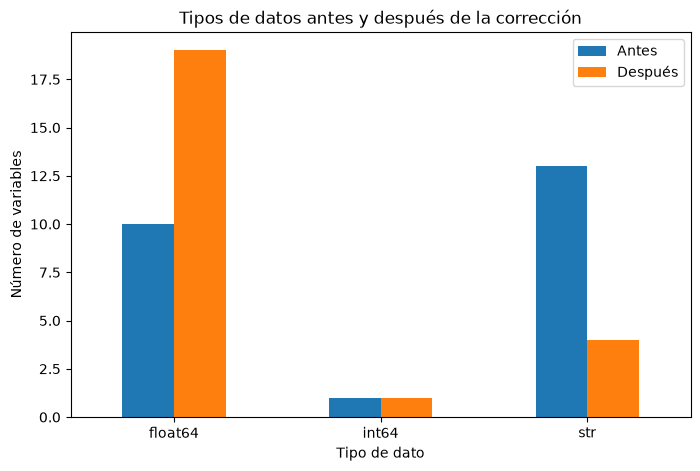

In [83]:
tipos_antes = df_antes_limpieza.dtypes.astype(str).value_counts()
tipos_despues = df.dtypes.astype(str).value_counts()

comparacion_tipos = pd.DataFrame({
    'Antes': tipos_antes,
    'Después': tipos_despues
}).fillna(0)

comparacion_tipos.plot(
    kind='bar',
    figsize=(8, 5)
)
plt.title('Tipos de datos antes y después de la corrección')
plt.xlabel('Tipo de dato')
plt.ylabel('Número de variables')
plt.xticks(rotation=0)
plt.show()

También en la variable edad se identificaron cinco registros con valores fuera del rango esperado. Estos valores afectaban considerablemente la distribución y la desviación estándar de la variable, por lo que se consideró necesario tratarlos antes de continuar con el procesamiento. En lugar de eliminar completamente los registros, los valores anómalos de edad fueron reemplazados por valores faltantes (NaN), permitiendo conservar el resto de la información disponible para cada participante.

In [84]:
# Identificar edades fuera del rango válido
edades_fuera_rango = df[(df['edad'] < 0) | (df['edad'] > 120)]

print(f"Número de valores fuera de rango: {len(edades_fuera_rango)}")
print(edades_fuera_rango['edad'])

Número de valores fuera de rango: 4
244    -7975.0
1155   -7975.0
1277   -7975.0
2388   -7975.0
Name: edad, dtype: float64


In [85]:
# Reemplazar edades fuera del rango válido por NaN
df.loc[(df['edad'] < 0) | (df['edad'] > 120), 'edad'] = np.nan
# Comprobar que ya no existen edades fuera del rango
print("Valores fuera de rango:",
      ((df['edad'] < 0) | (df['edad'] > 120)).sum())

print("Valores faltantes en edad:",
      df['edad'].isna().sum())

Valores fuera de rango: 0
Valores faltantes en edad: 29


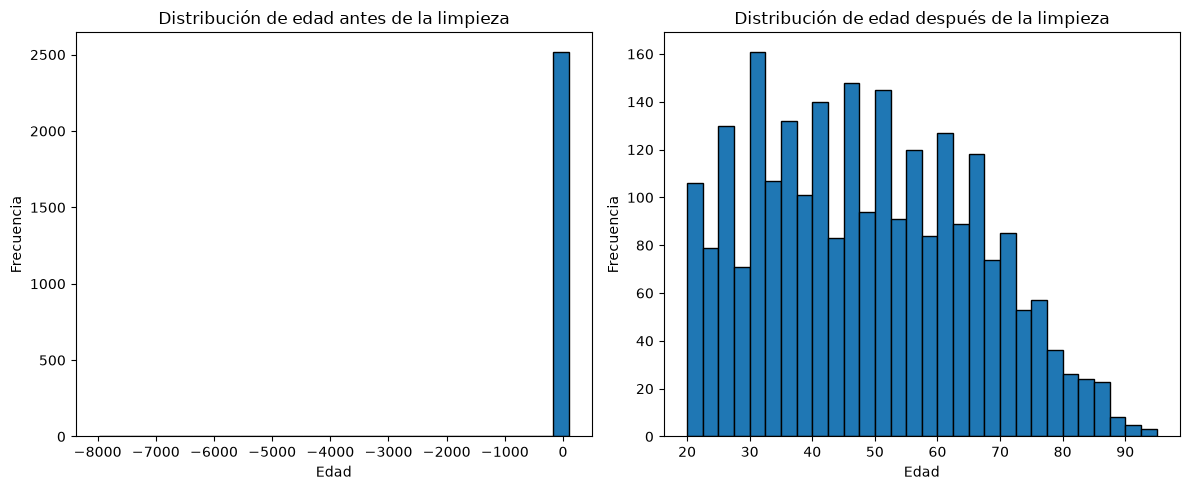

,Antes,Después
Media,35.763074,48.478571
Desviación estándar,319.672846,17.028860


In [86]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Antes
axes[0].hist(df_antes_limpieza['edad'].dropna(), bins=30, edgecolor='black')
axes[0].set_title('Distribución de edad antes de la limpieza')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')

# Después
axes[1].hist(df['edad'].dropna(), bins=30, edgecolor='black')
axes[1].set_title('Distribución de edad después de la limpieza')
axes[1].set_xlabel('Edad')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

comparacion_edad = pd.DataFrame({
    'Antes': [
        df_antes_limpieza['edad'].mean(),
        df_antes_limpieza['edad'].std()
    ],
    'Después': [
        df['edad'].mean(),
        df['edad'].std()
    ]
}, index=['Media', 'Desviación estándar'])

comparacion_edad

Al comparar la distribución de la edad antes y después de la limpieza, se observa que la presencia de únicamente cinco valores fuera del rango esperado tenía un efecto considerable sobre la dispersión de los datos, particularmente sobre la desviación estándar. Después de reemplazar estos valores anómalos por valores faltantes, la distribución representa de manera más adecuada las edades de la población estudiada y la desviación estándar disminuye considerablemente. Lo que se puede hacer para ir odavia un paso más es rellenar esas edades duera de rango que se pasaron a Nan por la mediana de la variable. La mediana es una buena opción ya que es menos sensible a los valores extremos presentes que la media. 

In [87]:
# Calcular la mediana de la edad después de eliminar los valores fuera de rango
mediana_edad = df['edad'].median()

print(f"Mediana de edad: {mediana_edad}")

# Reemplazar los valores NaN por la mediana
df['edad'] = df['edad'].fillna(mediana_edad)

# Verificar que ya no existan valores faltantes
print(f"Valores faltantes en edad después de la imputación: {df['edad'].isna().sum()}")

Mediana de edad: 48.0
Valores faltantes en edad después de la imputación: 0


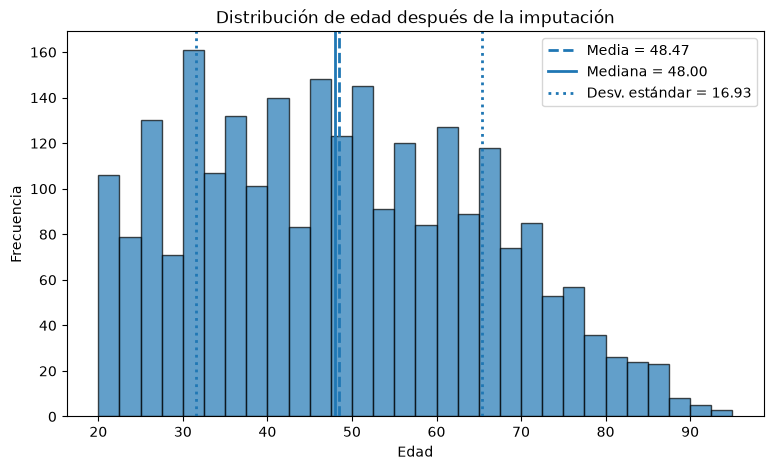

In [88]:
# Calcular estadísticas después de la imputación
media_final = df['edad'].mean()
mediana_final = df['edad'].median()
std_final = df['edad'].std()

# Crear histograma
plt.figure(figsize=(9, 5))

plt.hist(
    df['edad'],
    bins=30,
    edgecolor='black',
    alpha=0.7
)

# Media
plt.axvline(
    media_final,
    linestyle='--',
    linewidth=2,
    label=f'Media = {media_final:.2f}'
)

# Mediana
plt.axvline(
    mediana_final,
    linestyle='-',
    linewidth=2,
    label=f'Mediana = {mediana_final:.2f}'
)

# Desviación estándar
plt.axvline(
    media_final - std_final,
    linestyle=':',
    linewidth=2,
    label=f'Desv. estándar = {std_final:.2f}'
)

plt.axvline(
    media_final + std_final,
    linestyle=':',
    linewidth=2
)

plt.title('Distribución de edad después de la imputación')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.legend()

plt.show()

### Extracción de caracteristicas 
El objetivo de este proceso es obtener representaciones que puedan aportar información adicional al análisis sin necesidad de recolectar nuevos datos. Durante el análisis se pudo indentificar que la variable de indice de masa corporal (IMC) presenta la mayor cantidad de valores faltantes dentro del dataset. Sin embargo, debido a que el IMC se calcula directamente a partir del peso y la estatura, es posible obtener su valor para aquellos participantes que cuenten con ambas mediciones. Esto permite reducir la cantidad de datos faltantes y recuperar información útil sin introducir valores estimados de manera arbitraria.

In [162]:
# Calcular el IMC a partir del peso y la estatura
df['imc_calculado'] = df['Peso'] / (df['Estatura'] ** 2)
# Convertir la estatura de centímetros a metros y calcular el IMC
df['imc_calculado'] = df['Peso'] / ((df['Estatura'] / 100) ** 2)
display(
    df[['Peso', 'Estatura', 'imc', 'imc_calculado']]
    .head(15)
)
# Estadísticas descriptivas del IMC calculado
display(df['imc_calculado'].describe())

,Peso,Estatura,imc,imc_calculado
0,NaN,NaN,NaN,NaN
1,NaN,NaN,32.0,NaN
2,80.25,170.6,NaN,27.573188
3,68.60,166.2,NaN,24.834881
4,NaN,NaN,NaN,NaN
5,80.15,169.0,NaN,28.062743
6,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN
8,56.30,151.8,NaN,24.432328
9,NaN,NaN,NaN,NaN


count    1829.000000
mean       29.853513
std         6.162887
min        12.446114
25%        25.783203
50%        29.029591
75%        33.163758
max        65.552663
Name: imc_calculado, dtype: float64

A partir de las variables Peso y Estatura se creó la característica imc_calculado. El cálculo únicamente se realiza para aquellos registros que cuentan con ambas mediciones disponibles. Una vez calculado el IMC, se revisaron los primeros registros y sus estadísticas descriptivas para comprobar que los valores obtenidos fueran consistentes con las variables utilizadas para su cálculo.

In [91]:
print(
    "Valores disponibles de IMC original:",
    df['imc'].notna().sum()
)

print(
    "Valores disponibles de IMC calculado:",
    df['imc_calculado'].notna().sum()
)

Valores disponibles de IMC original: 35
Valores disponibles de IMC calculado: 1829


Para validar los datos generados, se seleccionaron los registros que contaban tanto con el IMC original como con el IMC calculado. Esto permite comparar ambas variables y determinar si el cálculo realizado a partir del peso y la estatura produce valores consistentes con los registrados originalmente.

In [92]:
# Seleccionar registros que tengan ambos valores de IMC
comparacion_imc = df[
    ['imc', 'imc_calculado']
].dropna()

print(
    "Registros disponibles para comparación:",
    len(comparacion_imc)
)

display(comparacion_imc.head(10))
# Calcular la diferencia absoluta entre ambos valores
comparacion_imc = comparacion_imc.copy()

comparacion_imc['diferencia'] = abs(
    comparacion_imc['imc'] -
    comparacion_imc['imc_calculado']
)

display(comparacion_imc.describe())
print(
    "Diferencia absoluta promedio:",
    comparacion_imc['diferencia'].mean()
)

Registros disponibles para comparación: 22


,imc,imc_calculado
135,15.0,14.997595
152,30.0,30.004918
176,33.0,33.003377
403,24.0,23.995904
511,32.0,31.996210
516,28.0,28.004550
716,25.0,24.995991
935,34.0,33.998799
954,32.0,32.002456
1198,28.0,28.003565


,imc,imc_calculado,diferencia
count,22.000000,22.000000,22.000000
mean,30.772727,30.772971,0.002111
std,8.479285,8.479563,0.001576
min,15.000000,14.997595,0.000039
25%,25.000000,25.000616,0.000731
50%,29.500000,29.499791,0.001705
75%,33.750000,33.749943,0.003518
max,56.000000,55.999825,0.004918


Diferencia absoluta promedio: 0.0021107454446901127


La pequeña diferencia absoluta entre el IMC registrado originalmente y el calculado a partir del peso y la estatura indica que los nuevos datos se callcularon de manera adecuada los valores del IMC original. Ahora se va comprobar gráficamente. 

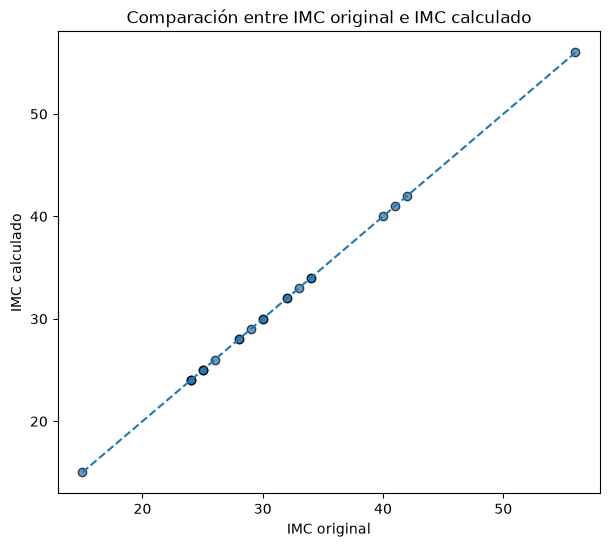

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    comparacion_imc['imc'],
    comparacion_imc['imc_calculado'],
    alpha=0.7,
    edgecolor='black'
)

# Línea de referencia: IMC original = IMC calculado
minimo = min(
    comparacion_imc['imc'].min(),
    comparacion_imc['imc_calculado'].min()
)

maximo = max(
    comparacion_imc['imc'].max(),
    comparacion_imc['imc_calculado'].max()
)

plt.plot(
    [minimo, maximo],
    [minimo, maximo],
    linestyle='--'
)

plt.title('Comparación entre IMC original e IMC calculado')
plt.xlabel('IMC original')
plt.ylabel('IMC calculado')

plt.show()

Como se observa en la gráfica, los valores del IMC calculado se encuentran prácticamente sobre la línea de referencia, la cual representa una correspondencia exacta entre el IMC original y el calculado.

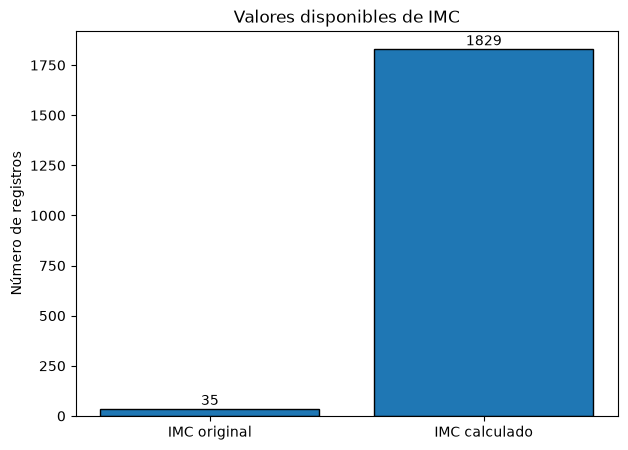

In [94]:
disponibles = {
    'IMC original': df['imc'].notna().sum(),
    'IMC calculado': df['imc_calculado'].notna().sum()
}

plt.figure(figsize=(7, 5))

barras = plt.bar(
    disponibles.keys(),
    disponibles.values(),
    edgecolor='black'
)

plt.title('Valores disponibles de IMC')
plt.ylabel('Número de registros')

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 20,
        str(int(altura)),
        ha='center'
    )

plt.show()

### Aumento de datos

Se observo en el análisis de data set que la variable objetivo presenta un desbalance considerable entre sus categorías, especialmente en la clase 1. Este desbalance puede dificultar que un modelo identifique adecuadamente los patrones asociados con la clase minoritaria.
Para reducir este problema se utilizará SMOTE-NC, una variante de SMOTE diseñada para conjuntos tabulares que contienen una combinación de características numéricas y categóricas.

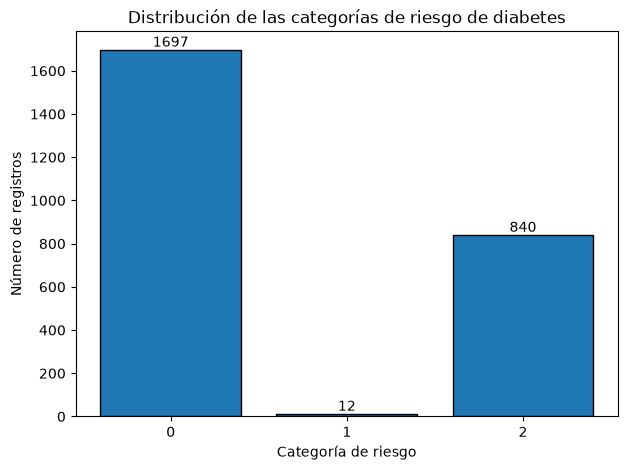

In [97]:
# Distribución de la variable objetivo
distribucion = (
    pd.to_numeric(df['riesgo_diabetes_cat'], errors='coerce')
    .value_counts()
    .reindex([0, 1, 2], fill_value=0)
    .sort_index()
)

plt.figure(figsize=(7, 5))

barras = plt.bar(
    distribucion.index.astype(str),
    distribucion.values,
    edgecolor='black'
)

plt.title('Distribución de las categorías de riesgo de diabetes')
plt.xlabel('Categoría de riesgo')
plt.ylabel('Número de registros')

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 15,
        str(int(altura)),
        ha='center'
    )

plt.show()

Antes de realizar el aumento se separará la variable objetivo de las características predictoras. Asimismo, se excluyeron los identificadores, ya que estos no representan características clínicas de los individuos. Se conservó imc_calculado en sustitución del IMC original, debido a que la nueva característica permitió disponer de esta información para una mayor cantidad de registros.

In [105]:
# Variable objetivo
y = df['riesgo_diabetes_cat'].copy()

# Variables predictoras
X = df.drop(
    columns=[
        'riesgo_diabetes_cat',
        'folio_i',
        'folio_int',
        'imc'
    ],
    errors='ignore'
).copy()
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

display(X.head())

Dimensiones de X: (2549, 21)
Dimensiones de y: (2549,)


,sexo,edad,Ciudad,Peso,Estatura,muestra_suero,ac_urico,albu,col_hdl,col_ldl,...,creat,glu_suero,insulina,trig,hb1ac,ponde_venosa,estrato,est_sel,ponde_hemo,imc_calculado
0,Mujer,89.0,AGUASCALIENTES,NaN,NaN,1.0,4.1,3.1,42.0,95.0,...,0.62,166.0,4.7,107.0,NaN,2245.917738,3.0,13.0,2888.530238,NaN
1,Mujer,71.0,AGUASCALIENTES,NaN,NaN,1.0,4.3,3.8,54.0,140.0,...,0.64,98.0,9.6,132.0,NaN,2245.917738,3.0,13.0,2888.530238,NaN
2,Mujer,57.0,AGUASCALIENTES,80.25,170.6,1.0,4.9,4.2,75.0,50.0,...,0.60,128.0,4.7,263.0,6.0,4047.445276,3.0,13.0,NaN,27.573188
3,Mujer,20.0,AGUASCALIENTES,68.60,166.2,1.0,4.9,4.4,68.0,66.0,...,0.63,112.0,10.1,238.0,NaN,13079.142320,3.0,13.0,13776.805260,24.834881
4,Hombre,74.0,AGUASCALIENTES,NaN,NaN,1.0,6.4,4.0,64.0,142.0,...,1.09,97.0,10.2,135.0,NaN,5292.158204,3.0,13.0,5824.779445,NaN


Debido a que el dataset contiene características numéricas y categóricas, estas se tienen que identificar por separado. Esta distinción es necesaria tanto para el tratamiento de los valores faltantes como para la posterior aplicación de SMOTE-NC.

In [106]:
display(X.dtypes)
columnas_categoricas = X.select_dtypes(
    include=['str', 'category', 'bool']
).columns.tolist()

columnas_numericas = X.select_dtypes(
    include='number'
).columns.tolist()

print("Variables categóricas:")
print(columnas_categoricas)

print("\nVariables numéricas:")
print(columnas_numericas)

sexo                 str
edad             float64
Ciudad               str
Peso             float64
Estatura         float64
muestra_suero    float64
ac_urico         float64
albu             float64
col_hdl          float64
col_ldl          float64
colest           float64
creat            float64
glu_suero        float64
insulina         float64
trig             float64
hb1ac            float64
ponde_venosa     float64
estrato          float64
est_sel          float64
ponde_hemo       float64
imc_calculado    float64
dtype: object

Variables categóricas:
['sexo', 'Ciudad']

Variables numéricas:
['edad', 'Peso', 'Estatura', 'muestra_suero', 'ac_urico', 'albu', 'col_hdl', 'col_ldl', 'colest', 'creat', 'glu_suero', 'insulina', 'trig', 'hb1ac', 'ponde_venosa', 'estrato', 'est_sel', 'ponde_hemo', 'imc_calculado']


Antes de realizar cualquier aumento de datos, el conjunto se dividió en entrenamiento y prueba. Esta separación se realizó previamente a SMOTE-NC para garantizar que las observaciones del conjunto de prueba permanezcan completamente independientes y representen únicamente datos reales.

In [107]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Train:", X_train.shape)
print("Test:", X_test.shape)

print("\nDistribución en entrenamiento:")
print(y_train.value_counts().sort_index())

print("\nDistribución en prueba:")
print(y_test.value_counts().sort_index())

Train: (2039, 21)
Test: (510, 21)

Distribución en entrenamiento:
riesgo_diabetes_cat
0    1357
1      10
2     672
Name: count, dtype: int64

Distribución en prueba:
riesgo_diabetes_cat
0    340
1      2
2    168
Name: count, dtype: int64


Debido a que SMOTE-NC requiere características completas para calcular las relaciones entre observaciones, se revisaron los valores faltantes presentes en el conjunto de entrenamiento antes de aplicar el aumento de datos.

In [108]:
faltantes_train = X_train.isnull().sum()

faltantes_train = (
    faltantes_train[faltantes_train > 0]
    .sort_values(ascending=False)
)

display(faltantes_train)
porcentaje_faltantes = (
    X_train.isnull().mean() * 100
)

porcentaje_faltantes = (
    porcentaje_faltantes[porcentaje_faltantes > 0]
    .sort_values(ascending=False)
)

display(porcentaje_faltantes.round(2))
umbral = 50

columnas_muchos_faltantes = porcentaje_faltantes[
    porcentaje_faltantes > umbral
].index.tolist()

print("Variables con más del 50 % de datos faltantes:")
print(columnas_muchos_faltantes)


hb1ac            1839
ponde_hemo        786
Estatura          574
Peso              574
imc_calculado     574
ponde_venosa       84
dtype: int64

hb1ac            90.19
ponde_hemo       38.55
Estatura         28.15
Peso             28.15
imc_calculado    28.15
ponde_venosa      4.12
dtype: float64

Variables con más del 50 % de datos faltantes:
['hb1ac']


In [109]:
X_train = X_train.drop(
    columns=columnas_muchos_faltantes
)

X_test = X_test.drop(
    columns=columnas_muchos_faltantes
)

Las características con más del 50 % de valores faltantes fueron excluidas para esta etapa, esto debido a que imputar variables con una ausencia tan elevada podría introducir una cantidad excesiva de valores estimados y alterar su distribución original.

In [110]:

# Volver a identificar las numéricas después de eliminar columnas
columnas_numericas = X_train.select_dtypes(
    include='number'
).columns.tolist()

imputador_numerico = SimpleImputer(
    strategy='median'
)

X_train[columnas_numericas] = imputador_numerico.fit_transform(
    X_train[columnas_numericas]
)

X_test[columnas_numericas] = imputador_numerico.transform(
    X_test[columnas_numericas]
)

Para las características numéricas restantes, los valores faltantes fueron sustituidos mediante la mediana calculada exclusivamente sobre el conjunto de entrenamiento. Posteriormente, estas mismas medianas se utilizaron para transformar el conjunto de prueba. En el caso de las características categóricas, los valores faltantes fueron sustituidos por la categoría más frecuente en el conjunto de entrenamiento. 

In [111]:
columnas_categoricas = X_train.select_dtypes(
    include=['str', 'category', 'bool']
).columns.tolist()

imputador_categorico = SimpleImputer(
    strategy='most_frequent'
)

X_train[columnas_categoricas] = imputador_categorico.fit_transform(
    X_train[columnas_categoricas]
)

X_test[columnas_categoricas] = imputador_categorico.transform(
    X_test[columnas_categoricas]
)
print(
    "Valores faltantes en entrenamiento:",
    X_train.isnull().sum().sum()
)

print(
    "Valores faltantes en prueba:",
    X_test.isnull().sum().sum()
)

Valores faltantes en entrenamiento: 0
Valores faltantes en prueba: 0


Después de realizar la imputación se verificó que los conjuntos de entrenamiento y prueba no conservaran valores faltantes. Con ello, los datos quedaron preparados para aplicar SMOTE-NC.

In [112]:
indices_categoricos = [
    X_train.columns.get_loc(col)
    for col in columnas_categoricas
]

print("Índices de variables categóricas:")
print(indices_categoricos)
print(y_train.value_counts().sort_index())
estrategia = {
    1: 300
}

Índices de variables categóricas:
[0, 2]
riesgo_diabetes_cat
0    1357
1      10
2     672
Name: count, dtype: int64


Debido al número extremadamente reducido de observaciones reales pertenecientes a la clase 1, se optó por realizar un aumento moderado en lugar de igualar completamente. Se estableció como objetivo generar un total de 300 observaciones para la clase minoritaria.

ANTES DE SMOTE-NC
riesgo_diabetes_cat
0    1357
1      10
2     672
Name: count, dtype: int64

DESPUÉS DE SMOTE-NC
riesgo_diabetes_cat
0    1357
1     300
2     672
Name: count, dtype: int64


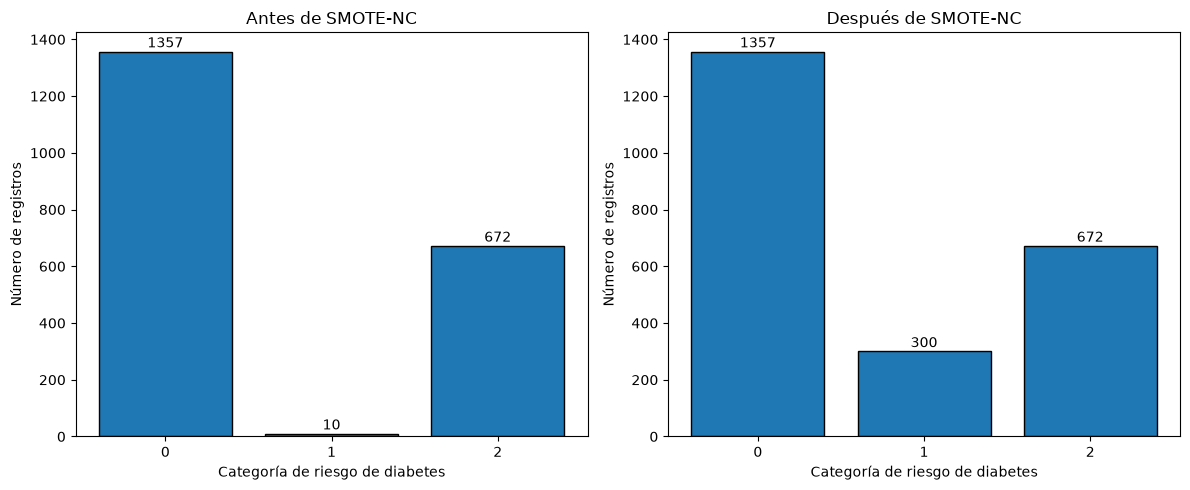

In [113]:
smote_nc = SMOTENC(
    categorical_features=indices_categoricos,
    sampling_strategy=estrategia,
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote_nc.fit_resample(
    X_train,
    y_train
)
print("ANTES DE SMOTE-NC")
print(y_train.value_counts().sort_index())

print("\nDESPUÉS DE SMOTE-NC")
print(y_train_smote.value_counts().sort_index())
antes = y_train.value_counts().sort_index()
despues = y_train_smote.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Antes
axes[0].bar(
    antes.index.astype(str),
    antes.values,
    edgecolor='black'
)

axes[0].set_title('Antes de SMOTE-NC')
axes[0].set_xlabel('Categoría de riesgo de diabetes')
axes[0].set_ylabel('Número de registros')

for i, valor in enumerate(antes.values):
    axes[0].text(i, valor + 15, str(valor), ha='center')

# Después
axes[1].bar(
    despues.index.astype(str),
    despues.values,
    edgecolor='black'
)

axes[1].set_title('Después de SMOTE-NC')
axes[1].set_xlabel('Categoría de riesgo de diabetes')
axes[1].set_ylabel('Número de registros')

for i, valor in enumerate(despues.values):
    axes[1].text(i, valor + 15, str(valor), ha='center')

plt.tight_layout()
plt.show()

Una vez aplicado SMOTE-NC, se comparó la distribución de la variable objetivo antes y después del aumento. Se observa una mayor representación de la clase minoritaria, mientras que las demás clases conservaron su número original de registros. A continuación, se evaluará si los datos sintéticos generados mantienen características similares a las observaciones originales.

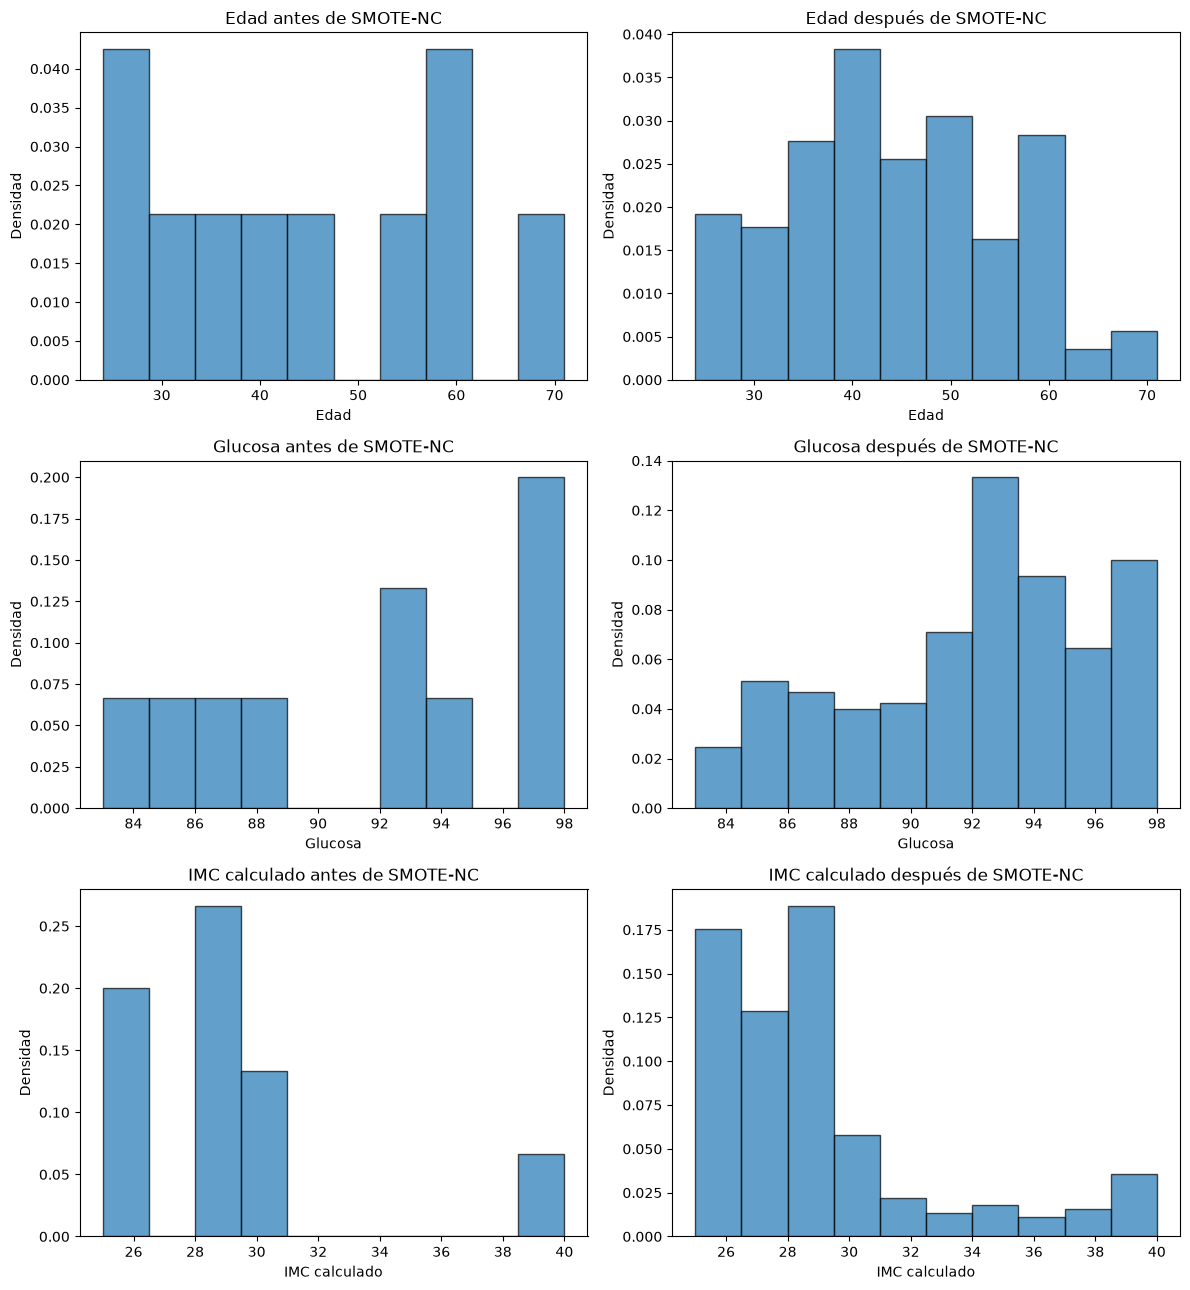

In [114]:
# Seleccionar solamente la clase aumentada
X_antes = X_train[y_train == 1]
X_despues = X_train_smote[y_train_smote == 1]

variables = [
    'edad',
    'glu_suero',
    'imc_calculado'
]

titulos = [
    'Edad',
    'Glucosa',
    'IMC calculado'
]

fig, axes = plt.subplots(3, 2, figsize=(12, 13))

for i, (variable, titulo) in enumerate(zip(variables, titulos)):

    minimo = min(
        X_antes[variable].min(),
        X_despues[variable].min()
    )

    maximo = max(
        X_antes[variable].max(),
        X_despues[variable].max()
    )

    # Antes
    axes[i, 0].hist(
        X_antes[variable],
        bins=10,
        range=(minimo, maximo),
        density=True,
        edgecolor='black',
        alpha=0.7
    )

    axes[i, 0].set_title(
        f'{titulo} antes de SMOTE-NC'
    )
    axes[i, 0].set_xlabel(titulo)
    axes[i, 0].set_ylabel('Densidad')

    # Después
    axes[i, 1].hist(
        X_despues[variable],
        bins=10,
        range=(minimo, maximo),
        density=True,
        edgecolor='black',
        alpha=0.7
    )

    axes[i, 1].set_title(
        f'{titulo} después de SMOTE-NC'
    )
    axes[i, 1].set_xlabel(titulo)
    axes[i, 1].set_ylabel('Densidad')

plt.tight_layout()
plt.show()

In [ ]:
print("Estadísticas antes de SMOTE-NC:")

display(
    X_antes[
        ['edad', 'glu_suero', 'imc_calculado']
    ].describe()
)

print("Estadísticas después de SMOTE-NC:")

display(
    X_despues[
        ['edad', 'glu_suero', 'imc_calculado']
    ].describe()
)

Estadísticas antes de SMOTE-NC:


,edad,glu_suero,imc_calculado
count,10.000000,10.000000,10.000000
mean,44.600000,91.600000,29.115105
std,16.242605,5.501515,4.280887
min,24.000000,83.000000,24.995991
25%,32.500000,87.250000,26.502310
50%,41.500000,93.000000,29.047369
75%,58.500000,96.250000,29.761558
max,71.000000,98.000000,40.001846


Estadísticas después de SMOTE-NC:


,edad,glu_suero,imc_calculado
count,300.000000,300.000000,300.000000
mean,44.443412,92.020701,29.017384
std,11.160220,3.992566,3.698194
min,24.000000,83.000000,24.995991
25%,36.953422,89.165136,26.377724
50%,43.036548,93.000000,28.360152
75%,52.254622,94.988322,29.540055
max,71.000000,98.000000,40.001846


Después de aplicar SMOTE-NC se observó un incremento en la representación de la clase 1, mientras que las clases restantes conservaron su número original de observaciones. Para evaluar la calidad de los datos generados se compararon las distribuciones y estadísticas descriptivas de edad, glucosa e imc_calculado antes y después del aumento. Esta comparación permite determinar si las observaciones sintéticas mantienen características similares a los registros reales y detectar posibles alteraciones importantes en sus distribuciones.

### Selección de características

Este procesamiento tiene como objetivo identificar aquellas variables que aportan mayor información para el problema analizado y eliminar características irrelevantes o redundantes, permientiendo asireducir la complejidad del dataset y disminuir la presencia de información que podría introducir ruido en modelos posteriores.

En este análisis se utilizará un método de tipo filter basado en Mutual Information, el cual permite estimar la dependencia existente entre cada característica y la variable objetivo. 

In [115]:
# Crear copias para la selección de características
X_seleccion = X_train.copy()
y_seleccion = y_train.copy()

print("Dimensiones:")
print("X:", X_seleccion.shape)
print("y:", y_seleccion.shape)

Dimensiones:
X: (2039, 20)
y: (2039,)


In [116]:
# Crear copias para la selección de características
X_seleccion = X_train.copy()
y_seleccion = y_train.copy()

print("Dimensiones:")
print("X:", X_seleccion.shape)
print("y:", y_seleccion.shape)

Dimensiones:
X: (2039, 20)
y: (2039,)


La selección de características se hizo únicamente con los datos de entrenamiento, evitando utilizar información del conjunto de prueba. Además, se usaron los datos antes de aplicar SMOTE-NC, para que los datos sintéticos no afectaran la selección de las variables más relevantes.

In [117]:
columnas_excluir = [
    'folio_i',
    'folio_int',
    'muestra_suero',
    'ponde_venosa',
    'ponde_hemo'
]

X_seleccion = X_seleccion.drop(
    columns=columnas_excluir,
    errors='ignore'
)

print("Variables restantes:")
print(X_seleccion.columns.tolist())

print("\nNúmero de variables:", X_seleccion.shape[1])

Variables restantes:
['sexo', 'edad', 'Ciudad', 'Peso', 'Estatura', 'ac_urico', 'albu', 'col_hdl', 'col_ldl', 'colest', 'creat', 'glu_suero', 'insulina', 'trig', 'estrato', 'est_sel', 'imc_calculado']

Número de variables: 17


Antes de realizar la selección, se eliminaron variables que no aportan información clínica relevante para la predicción, como identificadores, variables sin variación y aquellas relacionadas con el diseño o la ponderación de la muestra, quedando solo con las varaibles de arriba.

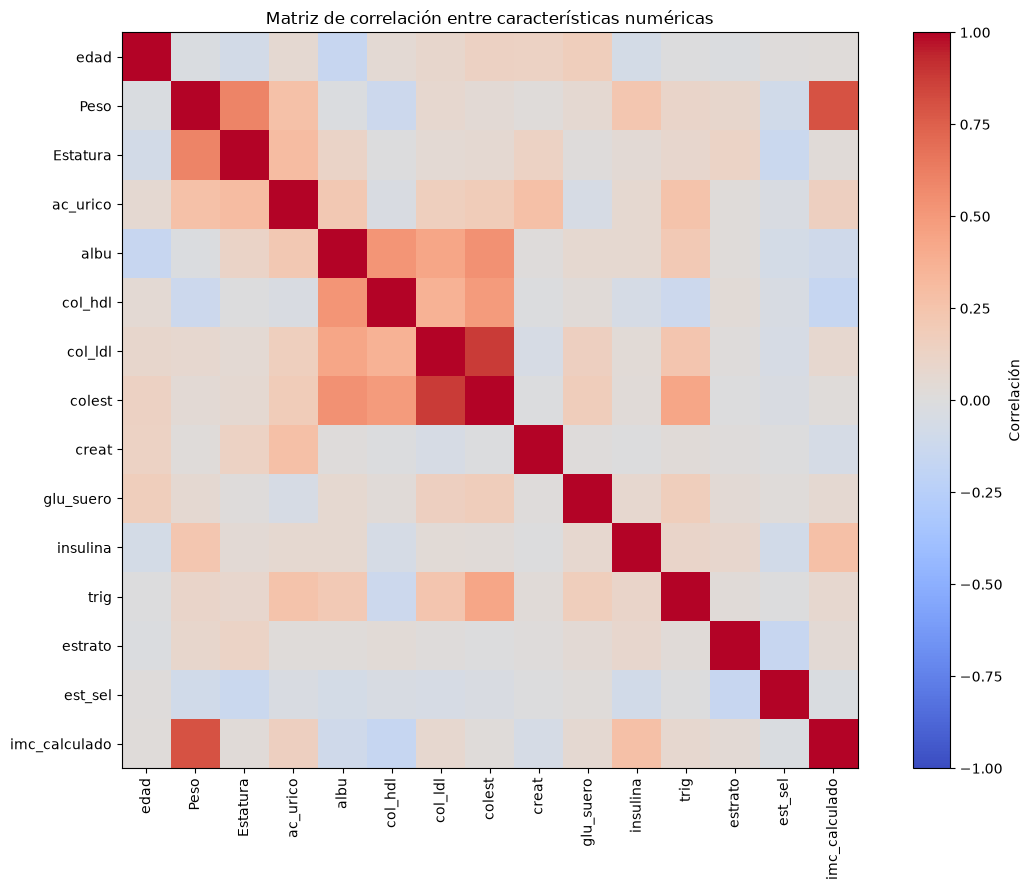

In [119]:
X_numericas = X_seleccion.select_dtypes(
    include='number'
)

correlacion = X_numericas.corr()
plt.figure(figsize=(12, 9))

plt.imshow(
    correlacion,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.colorbar(label='Correlación')

plt.xticks(
    range(len(correlacion.columns)),
    correlacion.columns,
    rotation=90
)

plt.yticks(
    range(len(correlacion.columns)),
    correlacion.columns
)

plt.title('Matriz de correlación entre características numéricas')

plt.tight_layout()
plt.show()

In [122]:
matriz_superior = correlacion.abs().where(
    np.triu(
        np.ones(correlacion.shape),
        k=1
    ).astype(bool)
)

pares_correlacionados = []

for columna in matriz_superior.columns:
    for fila in matriz_superior.index:

        valor = matriz_superior.loc[fila, columna]

        if pd.notna(valor) and valor >= 0.75:
            pares_correlacionados.append(
                (fila, columna, valor)
            )

pares_correlacionados = sorted(
    pares_correlacionados,
    key=lambda x: x[2],
    reverse=True
)

for var1, var2, corr in pares_correlacionados:
    print(
        f"{var1} - {var2}: {corr:.3f}"
    )

col_ldl - colest: 0.883
Peso - imc_calculado: 0.798


Se analizó la correlación entre las características numéricas para detectar posibles variables redundantes. Se revisaron aquellas con una correlación sea igual o mayor a 0.75 (que en este caso fdue el colesterol_ldl-colesterol total y el paso con el imc), aunque una correlación alta no significa necesariamente que una de las variables deba eliminarse, solo ayuda para tomar una mejor decisión en lo que sigue.

In [123]:
columnas_categoricas_mi = [
    col for col in columnas_categoricas
    if col in X_seleccion.columns
]

print("Categóricas utilizadas:")
print(columnas_categoricas_mi)


Categóricas utilizadas:
['sexo', 'Ciudad']


In [124]:
X_mi = X_seleccion.copy()

In [128]:
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_mi[columnas_categoricas_mi] = encoder.fit_transform(
    X_mi[columnas_categoricas_mi]
)
discrete_features = [
    columna in columnas_categoricas_mi
    for columna in X_mi.columns
]

for columna, discreta in zip(
    X_mi.columns,
    discrete_features
):
    print(
        f"{columna}: "
        f"{'Categórica' if discreta else 'Continua'}"
    )

sexo: Categórica
edad: Continua
Ciudad: Categórica
Peso: Continua
Estatura: Continua
ac_urico: Continua
albu: Continua
col_hdl: Continua
col_ldl: Continua
colest: Continua
creat: Continua
glu_suero: Continua
insulina: Continua
trig: Continua
estrato: Continua
est_sel: Continua
imc_calculado: Continua


In [129]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_mi,
    y_seleccion,
    discrete_features=discrete_features,
    random_state=42
)
tabla_mi = pd.DataFrame({
    'Característica': X_mi.columns,
    'Mutual Information': mi_scores
})

tabla_mi = tabla_mi.sort_values(
    by='Mutual Information',
    ascending=False
).reset_index(drop=True)

display(tabla_mi)

,Característica,Mutual Information
0,glu_suero,0.571674
1,Ciudad,0.110180
2,edad,0.061977
3,insulina,0.034372
4,imc_calculado,0.033664
5,Estatura,0.032107
6,trig,0.029023
7,colest,0.022026
8,Peso,0.020907
9,creat,0.020279


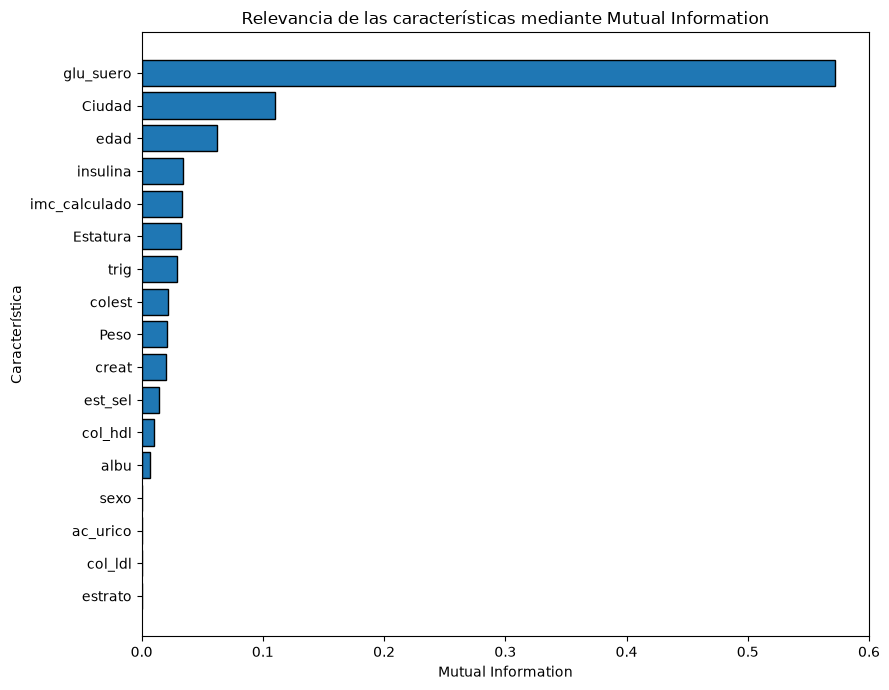

In [130]:
plt.figure(figsize=(9, 7))

plt.barh(
    tabla_mi['Característica'],
    tabla_mi['Mutual Information'],
    edgecolor='black'
)

plt.xlabel('Mutual Information')
plt.ylabel('Característica')
plt.title(
    'Relevancia de las características mediante Mutual Information'
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

La gráfica muestra la relevancia de cada característica respecto a la variable objetivo. Un valor mayor de Mutual Information indica una mayor relación con `riesgo_diabetes_cat`, mientras que valores cercanos a cero indican que la característica aporta poca información por sí sola, pero se sabe que no se recomiendo en automatico eliminar estas variables porque si podrian ofrecer más información en conjunto con otras.

In [131]:
k = 10

mejores_caracteristicas = (
    tabla_mi
    .head(k)['Característica']
    .tolist()
)

print(f"Top {k} características:")
for i, caracteristica in enumerate(
    mejores_caracteristicas,
    start=1
):
    print(f"{i}. {caracteristica}")
    X_train_seleccionado = X_train[
    mejores_caracteristicas
].copy()

X_test_seleccionado = X_test[
    mejores_caracteristicas
].copy()

Top 10 características:
1. glu_suero
2. Ciudad
3. edad
4. insulina
5. imc_calculado
6. Estatura
7. trig
8. colest
9. Peso
10. creat


A partir de los resultados de Mutual Information, se seleccionaron las características con mayor puntuación mediante un criterio Top-K. De esta forma, no se eliminaron automáticamente las variables con valores bajos, ya que podrían aportar información al combinarse con otras características.

In [132]:
print(
    "Número de características antes de la selección:",
    X_seleccion.shape[1]
)

print(
    "Número de características después de la selección:",
    X_train_seleccionado.shape[1]
)
reduccion = (
    1 -
    X_train_seleccionado.shape[1]
    / X_seleccion.shape[1]
) * 100

print(
    f"Reducción en el número de características: "
    f"{reduccion:.2f}%"
)
tabla_mi['Seleccionada'] = (
    tabla_mi['Característica']
    .isin(mejores_caracteristicas)
)

display(tabla_mi)

Número de características antes de la selección: 17
Número de características después de la selección: 10
Reducción en el número de características: 41.18%


,Característica,Mutual Information,Seleccionada
0,glu_suero,0.571674,True
1,Ciudad,0.110180,True
2,edad,0.061977,True
3,insulina,0.034372,True
4,imc_calculado,0.033664,True
5,Estatura,0.032107,True
6,trig,0.029023,True
7,colest,0.022026,True
8,Peso,0.020907,True
9,creat,0.020279,True


La selección de características permitió reducir el número de variables conservando las más relevantes para la variable objetivo. Para ello, se consideró la naturaleza de las variables, su posible redundancia y su puntuación de Mutual Information. Sin embargo, estos resultados indican relevancia y no causalidad, y una puntuación baja no significa que una característica no pueda ser útil al combinarse con otras.

### Reducción de dimensionalidad

Después de la selección de características, se aplicó Análisis de Componentes Principales (PCA) para reducir la dimensionalidad de los datos. A diferencia de la selección anterior, PCA combina las variables originales para generar nuevos componentes, buscando conservar la mayor cantidad posible de información con un menor número de dimensiones.

In [136]:
X_train_seleccionado
# Crear copia para PCA
X_pca = X_train_seleccionado.copy()

print("Dimensiones antes de PCA:")
print(X_pca.shape)

print("\nCaracterísticas seleccionadas:")
print(X_pca.columns.tolist())

Dimensiones antes de PCA:
(2039, 10)

Características seleccionadas:
['glu_suero', 'Ciudad', 'edad', 'insulina', 'imc_calculado', 'Estatura', 'trig', 'colest', 'Peso', 'creat']


In [137]:
# Identificar las variables categóricas seleccionadas
categoricas_pca = [
    col for col in columnas_categoricas
    if col in X_pca.columns
]

print("Variables categóricas que no entrarán al PCA:")
print(categoricas_pca)

# Eliminarlas para realizar PCA únicamente con variables numéricas
X_pca = X_pca.drop(
    columns=categoricas_pca,
    errors='ignore'
)

print("\nVariables utilizadas en PCA:")
print(X_pca.columns.tolist())

print("\nNúmero de variables para PCA:")
print(X_pca.shape[1])

Variables categóricas que no entrarán al PCA:
['Ciudad']

Variables utilizadas en PCA:
['glu_suero', 'edad', 'insulina', 'imc_calculado', 'Estatura', 'trig', 'colest', 'Peso', 'creat']

Número de variables para PCA:
9


Como PCA trabaja con la varianza, se utilizaron únicamente las variables numéricas continuas seleccionadas previamente, dejando fuera las variables categóricas. Antes de aplicar PCA, las variables se deben estandarizar para que tengan una media cercana a 0 y una desviación estándar cercana a 1. Así se evita que las variables con escalas mayores tengan más influencia en la creación de los componentes.

In [143]:
scaler = StandardScaler()

X_pca_scaled = scaler.fit_transform(X_pca)
X_pca_scaled_df = pd.DataFrame(
    X_pca_scaled,
    columns=X_pca.columns,
    index=X_pca.index
)

display(
    X_pca_scaled_df.describe().round(2)
)

,glu_suero,edad,insulina,imc_calculado,Estatura,trig,colest,Peso,creat
count,2039.00,2039.00,2039.00,2039.00,2039.00,2039.00,2039.00,2039.00,2039.00
mean,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.40,-1.67,-0.78,-3.25,-3.44,-1.02,-2.77,-2.42,-1.00
25%,-0.44,-0.85,-0.45,-0.46,-0.46,-0.53,-0.65,-0.41,-0.33
50%,-0.27,-0.03,-0.24,-0.10,-0.07,-0.25,-0.09,-0.11,-0.12
75%,-0.02,0.73,0.13,0.34,0.34,0.22,0.53,0.23,0.14
max,19.24,2.67,25.38,6.82,6.48,21.35,11.37,8.05,22.83


In [147]:
pca = PCA()

X_pca_completo = pca.fit_transform(
    X_pca_scaled
)

print(
    "Número de componentes generados:",
    pca.n_components_
)
import numpy as np

varianza_explicada = (
    pca.explained_variance_ratio_
)

varianza_acumulada = np.cumsum(
    varianza_explicada
)

tabla_varianza = pd.DataFrame({
    'Componente': [
        f'PC{i+1}'
        for i in range(len(varianza_explicada))
    ],

    'Varianza explicada (%)':
        varianza_explicada * 100,

    'Varianza acumulada (%)':
        varianza_acumulada * 100
})

display(
    tabla_varianza.round(2)
)

Número de componentes generados: 9


,Componente,Varianza explicada (%),Varianza acumulada (%)
0,PC1,24.21,24.21
1,PC2,17.07,41.28
2,PC3,13.07,54.35
3,PC4,12.27,66.62
4,PC5,10.21,76.82
5,PC6,9.35,86.17
6,PC7,7.73,93.91
7,PC8,5.88,99.79
8,PC9,0.21,100.00


Para conocer cuánta información conserva cada componente, se calculó su porcentaje de varianza explicada y la varianza acumulada. Los primeros componentes concentran la mayor parte de la información, mientras que los siguientes agregan cantidades cada vez menores.

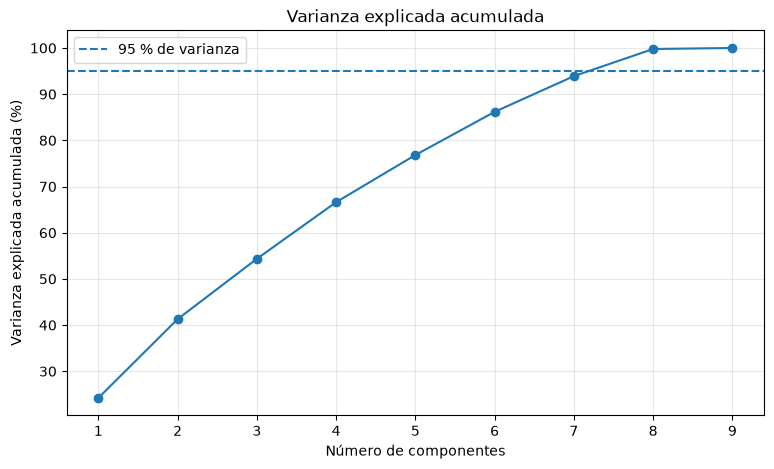

In [152]:
plt.figure(figsize=(9, 5))

plt.plot(
    componentes,
    varianza_acumulada * 100,
    marker='o'
)

# Línea del 95 %
plt.axhline(
    y=95,
    linestyle='--',
    label='95 % de varianza'
)

plt.xticks(componentes)

plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada (%)')

plt.title(
    'Varianza explicada acumulada'
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [154]:
n_componentes_95 = np.argmax(
    varianza_acumulada >= 0.95
) + 1

print(
    "Número mínimo de componentes para conservar "
    f"al menos el 95 % de la varianza: "
    f"{n_componentes_95}"
)

print(
    "Varianza acumulada conservada:",
    f"{varianza_acumulada[n_componentes_95 - 1] * 100:.2f}%"
)

Número mínimo de componentes para conservar al menos el 95 % de la varianza: 8
Varianza acumulada conservada: 99.79%


Se estableció como criterio conservar al menos el 95 % de la varianza acumulada, buscando reducir las dimensiones sin perder demasiada información. Al tratarse de datos relacionados con la salud, se consideró conveniente utilizar un porcentaje alto para conservar la mayor cantidad posible de información relevante. Se obtuvo que se deben conservar 8 componentes y esto va permitor conservar 99.79% de la varianza acomulada.

In [158]:
pca_final = PCA(
    n_components=n_componentes_95
)

X_train_pca = pca_final.fit_transform(
    X_pca_scaled
)
nombres_componentes = [
    f'PC{i+1}'
    for i in range(n_componentes_95)
]

X_train_pca = pd.DataFrame(
    X_train_pca,
    columns=nombres_componentes,
    index=X_pca.index
)

display(X_train_pca.head())
variables_originales = X_pca.shape[1]

componentes_finales = n_componentes_95

reduccion = (
    1 -
    componentes_finales / variables_originales
) * 100

print(
    "Variables antes de PCA:",
    variables_originales
)

print(
    "Componentes después de PCA:",
    componentes_finales
)

print(
    f"Reducción dimensional: {reduccion:.2f}%"
)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
865,-1.661488,0.336390,-0.801460,-0.722483,0.454587,-0.121937,-0.277220,1.135907
852,-2.142671,0.116080,0.474558,-1.331314,0.044977,0.471032,0.322964,0.330753
1868,-0.719740,0.200571,0.202415,-0.401735,0.070387,0.177099,-0.033614,0.148890
2352,-1.461207,-0.051451,-0.753755,0.884349,-0.154367,-0.694910,-0.423019,-0.097814
665,1.815446,-1.772798,1.056676,-0.043549,-1.219482,0.091818,0.680393,-0.684891


Variables antes de PCA: 9
Componentes después de PCA: 8
Reducción dimensional: 11.11%


Con el criterio del 95 % de varianza acumulada, se determinó que eran necesarios 8 componentes principales. De esta forma, las 9 variables originales se redujeron a 8 componentes, lo que representa una reducción dimensional del **11.11 %**. Aunque la reducción no fue muy grande, permitió disminuir la dimensionalidad conservando al menos el 95 % de la información presente en los datos.

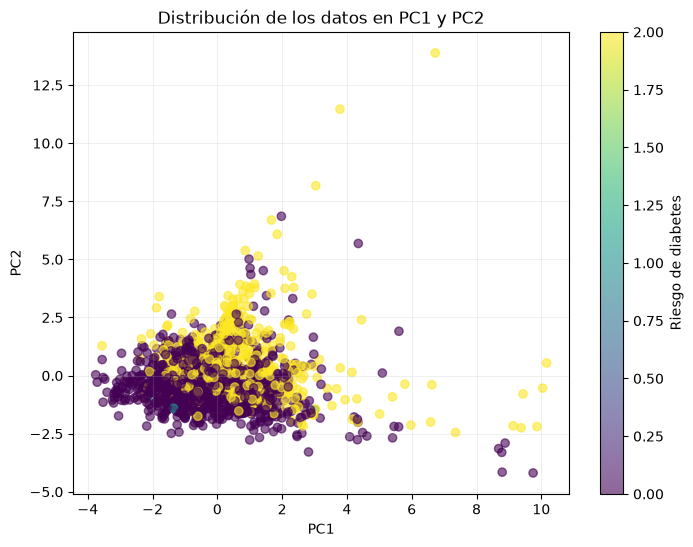

In [159]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_train_pca['PC1'],
    X_train_pca['PC2'],
    c=y_train.loc[X_train_pca.index],
    alpha=0.6
)

plt.xlabel('PC1')
plt.ylabel('PC2')

plt.title(
    'Distribución de los datos en PC1 y PC2'
)

plt.colorbar(
    scatter,
    label='Riesgo de diabetes'
)

plt.grid(alpha=0.2)

plt.show()

La representación de PC1 y PC2 muestra una alta superposición entre las categorías de riesgo de diabetes, sin una separación clara entre ellas. Esto indica que la variabilidad capturada por estos componentes no está directamente relacionada con la clasificación de la variable objetivo.

In [160]:
loadings = pd.DataFrame(
    pca_final.components_.T,
    index=X_pca.columns,
    columns=nombres_componentes
)

display(loadings.round(3))
for componente in nombres_componentes:

    print(f"\n{componente}")

    importancia = (
        loadings[componente]
        .abs()
        .sort_values(ascending=False)
    )

    display(
        importancia.head(5)
    )

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
glu_suero,0.134,0.409,-0.059,0.330,-0.067,0.788,-0.270,0.066
edad,-0.005,0.313,0.264,0.661,-0.236,-0.265,0.439,-0.277
insulina,0.290,-0.036,-0.350,0.126,0.704,0.124,0.514,0.016
imc_calculado,0.529,-0.181,-0.249,0.303,-0.098,-0.276,-0.345,0.078
Estatura,0.373,-0.093,0.522,-0.378,-0.152,0.304,0.378,-0.076
trig,0.221,0.529,-0.126,-0.358,0.136,-0.176,-0.208,-0.659
colest,0.158,0.603,-0.069,-0.228,-0.115,-0.260,0.161,0.669
Peso,0.635,-0.201,0.108,0.023,-0.183,-0.041,-0.060,0.013
creat,0.027,0.094,0.661,0.149,0.588,-0.156,-0.368,0.157



PC1


Peso             0.635302
imc_calculado    0.529380
Estatura         0.372974
insulina         0.290321
trig             0.221424
Name: PC1, dtype: float64


PC2


colest       0.602881
trig         0.529042
glu_suero    0.408946
edad         0.312503
Peso         0.200949
Name: PC2, dtype: float64

...

glu_suero        0.787681
Estatura         0.304410
imc_calculado    0.276332
edad             0.265173
colest           0.260280
Name: PC6, dtype: float64


PC7


insulina         0.513889
edad             0.438659
Estatura         0.377713
creat            0.368381
imc_calculado    0.345333
Name: PC7, dtype: float64


PC8


colest           0.669188
trig             0.658950
edad             0.276943
creat            0.156742
imc_calculado    0.077567
Name: PC8, dtype: float64

Finalmente, se analizaron los loadings de los componentes principales. Estos valores permiten identificar qué características originales tienen una mayor contribución en la construcción de cada componente.

Este  muestra que PC1 está principalmente relacionado con características antropométricas como `Peso` e `imc_calculado`, mientras que PC2 está más asociado con variables bioquímicas como `colest`, `trig` y `glu_suero`. Esto ayuda a explicar por qué estos componentes no separan claramente las categorías de riesgo, ya que PCA busca representar la variabilidad de los datos y no distinguir la variable objetivo.

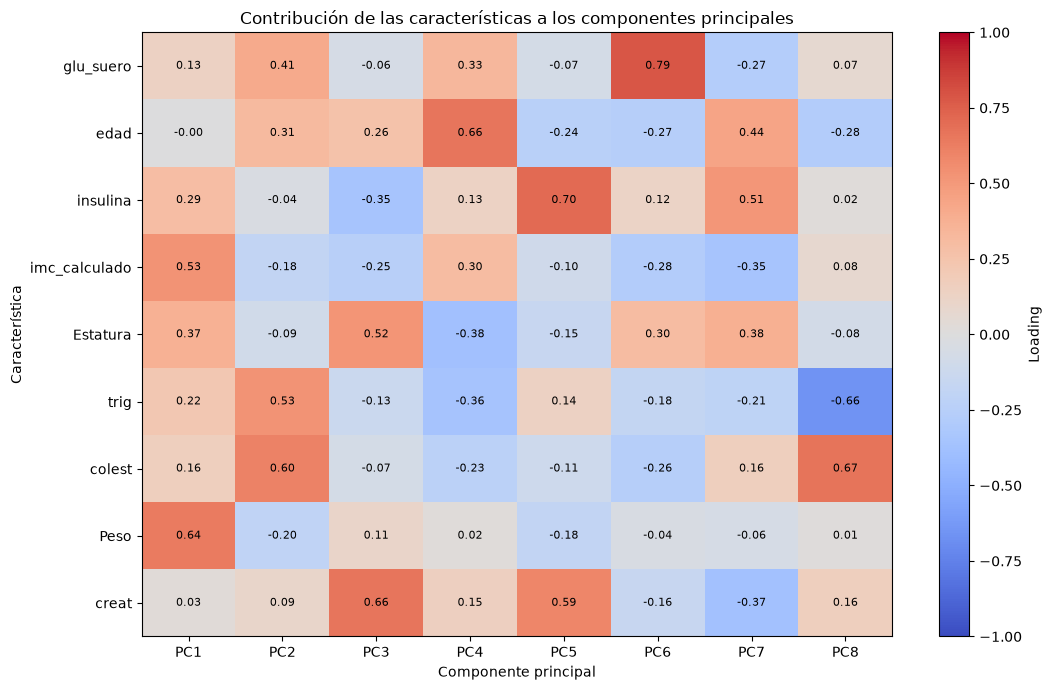

In [161]:
plt.figure(figsize=(11, 7))

plt.imshow(
    loadings,
    aspect='auto',
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.colorbar(label='Loading')

plt.xticks(
    range(len(loadings.columns)),
    loadings.columns
)

plt.yticks(
    range(len(loadings.index)),
    loadings.index
)

# Mostrar los valores dentro de cada celda
for i in range(len(loadings.index)):
    for j in range(len(loadings.columns)):
        plt.text(
            j,
            i,
            f'{loadings.iloc[i, j]:.2f}',
            ha='center',
            va='center',
            fontsize=8
        )

plt.title('Contribución de las características a los componentes principales')
plt.xlabel('Componente principal')
plt.ylabel('Característica')

plt.tight_layout()
plt.show()

El mapa de calor de los loadings muestra cómo la influencia de las características se distribuye entre los distintos componentes. PC1 y PC2 concentran principalmente información antropométrica y bioquímica, mientras que los componentes posteriores capturan información de características más específicas.

En resumen, PCA permitió reducir la dimensionalidad conservando al menos el 95 % de la varianza. Los componentes obtenidos combinan principalmente información antropométrica y bioquímica; sin embargo, PC1 y PC2 no muestran una separación clara entre las categorías de riesgo de diabetes.

### Conclusión
En esta práctica se realizó el preprocesamiento del dataset, identificando primero problemas como valores faltantes, datos fuera de rango, diferencias de escala y desbalance en la variable objetivo. A partir de esto, se aplicaron técnicas de limpieza y aumento de dato y extracción caracteristicas, incluyendo el cálculo del IMC y el balanceo mediante SMOTE-NC.

También se realizó una selección de características para conservar las variables más relevantes y se aplicó PCA para reducir la dimensionalidad manteniendo al menos el 95 % de la varianza. Los resultados mostraron que los componentes combinan información antropométrica y bioquímica, aunque no presentan una separación clara entre las categorías de riesgo de diabetes.

En conlusión, la práctica mostró la importancia del preprocesamiento para preparar datos reales antes del modelado. Cada técnica implica decisiones que pueden modificar la representación de los datos, por lo que deben aplicarse considerando las características del dataset, el objetivo del análisis y sus limitaciones.
### Referencias
De Santiago Nocito, A. (2010). Definición, clasificación clínica y diagnóstico de la diabetes mellitus. Documentos clinicos SEMERGEN.

Reyes-García, A., Basto-Abreu, A., Reyes-Sánchez, F., Stern, D., Romero-Martínez, M., Campos-Nonato, I., Rojas-Martínez, R., Aguilar-Salinas, C. A., & Barrientos-Gutiérrez, T. (2025). Prevalencia de diabetes y control glucémico en México, Ensanut 2021-2024. Salud Pública de México, 67(6 (nov-dic)), 622-632. https://doi.org/10.21149/17286 

Encuesta Nacional de Salud y Nutrición. (2024). ENCUESTAS. https://ensanut.insp.mx/encuestas/ensanutcontinua2024/descargas.php

Hernández-Ávila, M., Gutiérrez, J. P., & Reynoso-Noverón, N. (2013). Diabetes mellitus en México: El estado de la epidemia. Salud pública de México, 55, s129-s136. 

Axel Frederick Félix Jiménez, and Vania Stephany Sánchez Lee. (2026). Diabetes Mexico Data Set [Dataset]. Kaggle. https://doi.org/10.34740/KAGGLE/DSV/14619160 

### Declaración de uso de IA
Para el desarrollo de esta práctica se utilizó ChatGPT (OpenAI) como herramienta de apoyo para mejorar la redacción y para orientar algunos procedimientos de análisis y preprocesamiento de datos. Los resultados, el código y las interpretaciones obtenidas fueron revisados y ajustados antes de su incorporación a la práctica. 